In [1]:
import os
import h5py
import mediapy as media
import matplotlib.pyplot as plt

def load_hdf5(dataset_path):
    if not os.path.isfile(dataset_path):
        print(f'Dataset does not exist at \n{dataset_path}\n')
        exit()

    with h5py.File(dataset_path, 'r') as root:
        qpos = root['/observations/qpos'][()]
        qvel = root['/observations/qvel'][()]
        key_frame = root['/observations/key_frame'][()]
        image_dict = dict()
        for cam_name in root[f'/observations/images/'].keys():
            image_dict[cam_name] = root[f'/observations/images/{cam_name}'][()]
        action = root['/action'][()]

    return qpos, qvel, action, image_dict, key_frame

/home/vivekbagade/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [32]:
# play cam video
data_file = '/act-data/PickPlaceCan/episodes/1.0.0-sim/episode_28.hdf5'
qpos, qvel, action, image_dict, key_frames = load_hdf5(dataset_path=data_file)
for cam_name, image_list in image_dict.items():
    media.show_video(image_list, fps=30)

This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


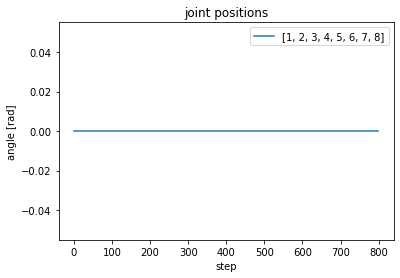

In [ ]:
# plot qpos
plt.figure()
plt.plot(qpos, label=list(range(1, 9)))
plt.xlabel('step')
plt.ylabel('angle [rad]')
plt.title('joint positions')
plt.legend()

Number of key frames: 85
Key frames for camera: birdview
Key frame at index 200


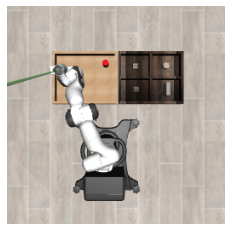

Key frame at index 209


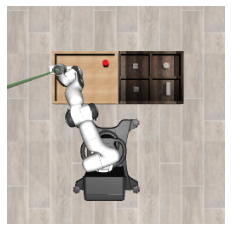

Key frame at index 493


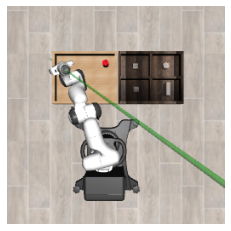

Key frame at index 548


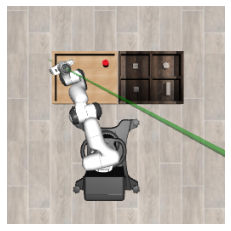

Key frame at index 553


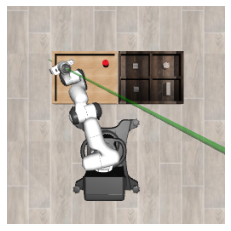

Key frame at index 559


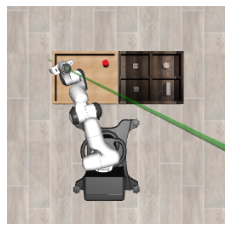

Key frame at index 567


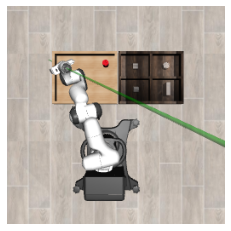

Key frame at index 572


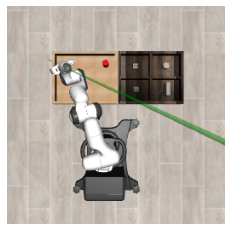

Key frame at index 578


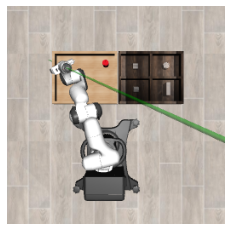

Key frame at index 590


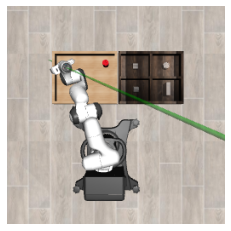

Key frames for camera: frontview
(256, 256, 3) uint8
Key frame at index 200


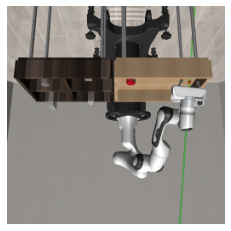

(256, 256, 3) uint8
Key frame at index 209


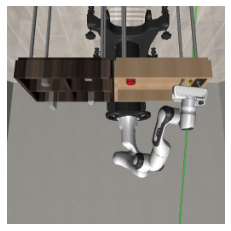

(256, 256, 3) uint8
Key frame at index 493


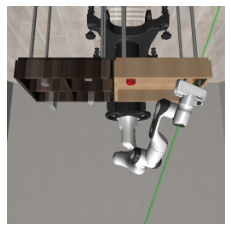

(256, 256, 3) uint8
Key frame at index 548


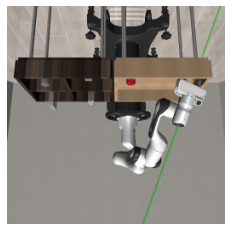

(256, 256, 3) uint8
Key frame at index 553


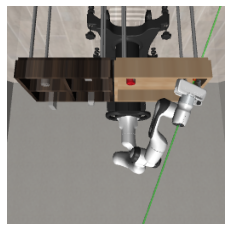

(256, 256, 3) uint8
Key frame at index 559


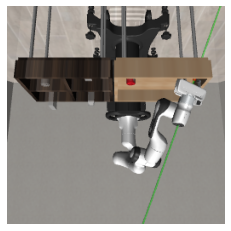

(256, 256, 3) uint8
Key frame at index 567


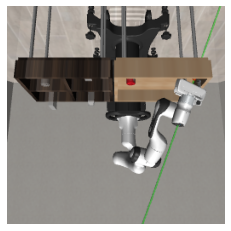

(256, 256, 3) uint8
Key frame at index 572


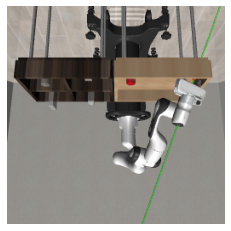

(256, 256, 3) uint8
Key frame at index 578


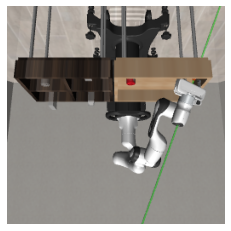

(256, 256, 3) uint8
Key frame at index 590


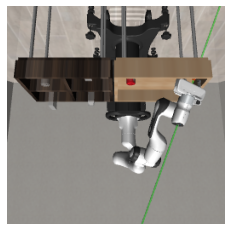

Key frames for camera: robot0_eye_in_hand
Key frame at index 200


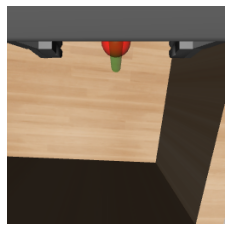

Key frame at index 209


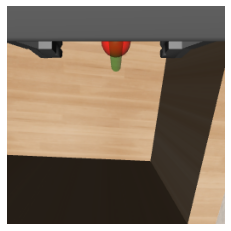

Key frame at index 493


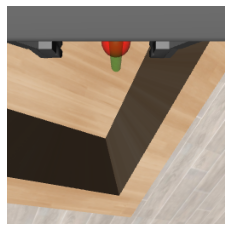

Key frame at index 548


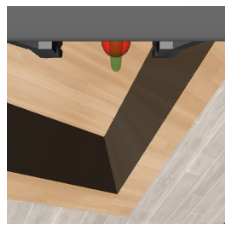

Key frame at index 553


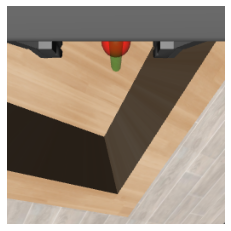

Key frame at index 559


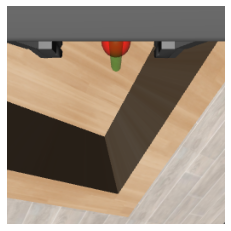

Key frame at index 567


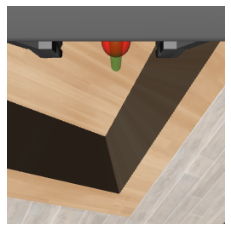

Key frame at index 572


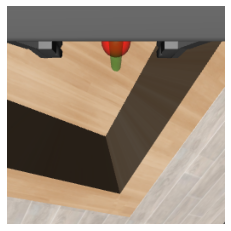

Key frame at index 578


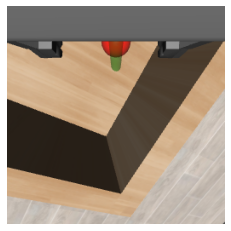

Key frame at index 590


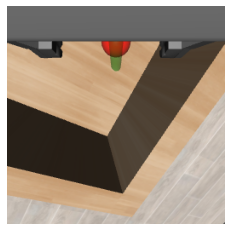

In [33]:
import numpy as np

num_key_frames = 0
for i in range(len(key_frames)):
    if key_frames[i]:
        num_key_frames += 1
print(f'Number of key frames: {num_key_frames}')

## Print the images of the indices where key_frames is True
max_frames = 10
for cam_name, image_list in image_dict.items():
    min_diff = 5
    last_key_frame = -min_diff
    print(f'Key frames for camera: {cam_name}')
    cur = 0
    for i in range(len(key_frames)):
        if key_frames[i] and (i - last_key_frame) >= min_diff:
            last_key_frame = i
            if cur >= max_frames:
                break
            cur += 1
            final = image_list[i]
            if cam_name == 'frontview':
                # Rotate the image 180 degrees
                print(final.shape, final.dtype)
                final = np.flip(final, axis=1)
            print(f'Key frame at index {i}')
            plt.figure()
            plt.imshow(final)
            plt.axis('off')
            plt.show()